In [1]:
# Zelle 1: Import testen
from data_reconciliation.io.reader import read_excel
from data_reconciliation.preprocessing.filter import IQRFilter, ResidualFilter, CompositeFilter, filter_report
from data_reconciliation.reconciliation.reconcile import reconcile
from data_reconciliation.visualization.plots import plot_raw_data, plot_corrections
from pathlib import Path

print("✓ Alle Module geladen")



✓ Alle Module geladen


In [2]:
# Zelle 2: Daten einlesen
ROOT = Path().resolve().parent        # funktioniert in Notebooks aus notebooks/
data = read_excel(ROOT / "data" / "demo-daten.xlsx")
X, A, rho = data["X"], data["A"], data["rho"]
print(f"X: {X.shape}, A: {A.shape}, rho: {rho}")



X: (3000, 5), A: (1, 5), rho: [0.02 0.05 0.02 0.02 0.05]


In [3]:
# Zelle 3: Filtern
f = CompositeFilter([IQRFilter(k=1.5), ResidualFilter(A, threshold=3.0)], mode="and")
detailed = f.fit(X).transform_detailed(X)
mask = detailed["combined"]
filter_report(mask, detailed)



---------------------------------------------
  Filterung: 3000 Zeitschritte total
  Behalten:  2613  (87.1%)
  Entfernt:  387  (12.9%)
  Einzelfilter:
    IQRFilter: 386 entfernt (12.9%)
    ResidualFilter: 25 entfernt (0.8%)
---------------------------------------------


In [4]:
# Zelle 4: Rekonziliation
result = reconcile(X[mask], A, rho)
print(f"Mittlerer SS_res: {result['SS_res'].mean():.6f}")



Mittlerer SS_res: 0.000000


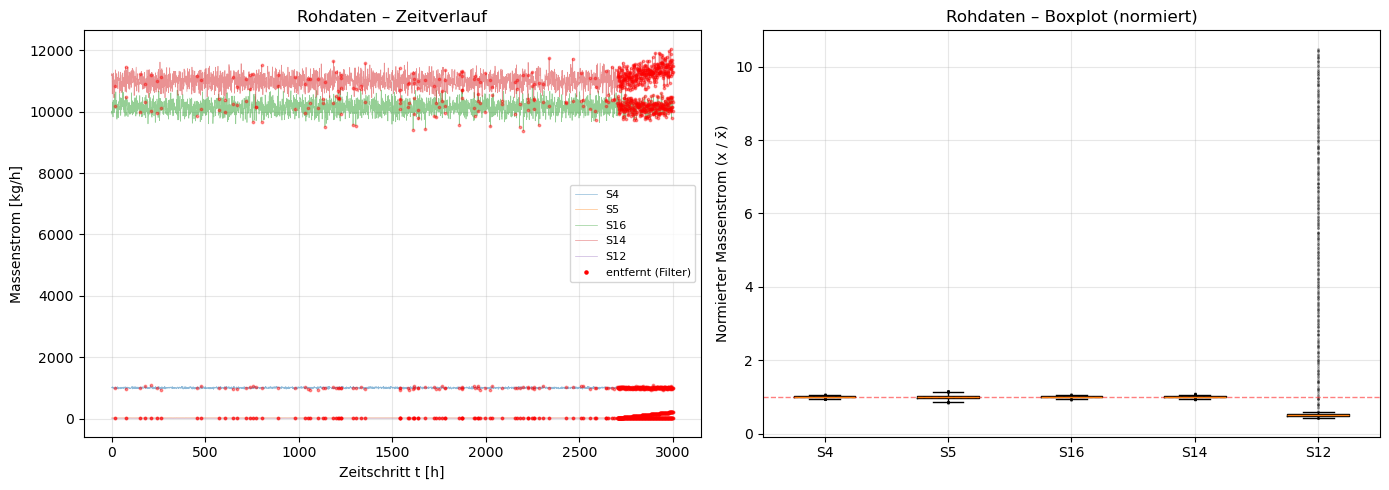

In [5]:
# Zelle 5: Plot
%matplotlib inline
fig = plot_raw_data(X, data["stream_ids"], mask=mask)